# Nhiệm vụ 7: Đánh giá Chất lượng Cụm (Cluster Quality Evaluation) — K-Means Baseline

Notebook này thực hiện đánh giá chất lượng hình học và độ phân tách toán học của mô hình **K-Means Baseline (Global K=2)** trên 15 snapshots của Cửa sổ phát triển (11/2023 – 01/2025) theo đúng quy chuẩn tại `M2/Ke_hoach_M2_Phan_cum_co_phieu.md`.

### Nguyên tắc thực thi bất biến:
- Tầng đánh giá chất lượng chỉ đọc dữ liệu chẩn đoán (`diagnostics.csv`) đã tạo sẵn từ pipeline Nhiệm vụ 4, **tuyệt đối không huấn luyện lại mô hình**.
- Hoạt động hoàn toàn độc lập với các thư viện chuẩn (`pandas`, `matplotlib`, `os`).
- Đánh giá dựa trên 5 chỉ số chất lượng nội bộ: Silhouette, Davies-Bouldin (DB), Calinski-Harabasz (CH), Inertia, và Cluster Balance.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Thiết lập đường dẫn tương thích linh hoạt (chạy từ repo root hoặc từ thư mục M2/notebooks)
diag_candidates = [
    "../artifacts/m2-task4-kmeans-baseline-v1/diagnostics.csv",
    "M2/artifacts/m2-task4-kmeans-baseline-v1/diagnostics.csv"
]
diag_path = next((p for p in diag_candidates if os.path.exists(p)), None)
if diag_path is None:
    raise FileNotFoundError("Không tìm thấy file diagnostics.csv của K-Means Baseline!")

out_candidates = [
    "../artifacts/m2-evaluation-kmeans",
    "M2/artifacts/m2-evaluation-kmeans"
]
out_dir = next((p for p in out_candidates if os.path.exists(os.path.dirname(p))), "M2/artifacts/m2-evaluation-kmeans")
os.makedirs(out_dir, exist_ok=True)

df_diag = pd.read_csv(diag_path)
df_k2 = df_diag[df_diag["k"] == 2].sort_values("snapshot_date").reset_index(drop=True)
print(f"Đã nạp thành công {len(df_k2)} snapshots cho cấu hình Global K = 2 từ {diag_path}")

Đã nạp thành công 15 snapshots cho cấu hình Global K = 2 từ M2/artifacts/m2-task4-kmeans-baseline-v1/diagnostics.csv


## 1. Phân cấp ưu tiên tiêu chí theo DELTA_UNIFIED_PROJECT_PLAN.md
- **Tiêu chí cấp 1 (Primary Criterion):** `Median Silhouette cao nhất`. Đây là cơ sở toán học cao nhất để chứng minh K=2 tạo ra ranh giới tách biệt rõ ràng nhất giữa các nhóm cổ phiếu trên thị trường Việt Nam.
- **Tiêu chí phá vỡ thế cân bằng (Secondary Tie-breaker):** `Median Davies-Bouldin thấp hơn`. Dùng khi Silhouette giữa các phương án xấp xỉ nhau.
- **Tiêu chí kiểm định an toàn (Sanity Diagnostics):** `Calinski-Harabasz` và `Cluster Balance` dùng để kiểm tra độ tin cậy, cảnh báo nguy cơ phân cụm bị chi phối bởi các cổ phiếu dị biệt.
- **Ranh giới phương pháp luận nghiêm ngặt:** Đánh giá chất lượng cụm hoàn toàn bằng các thước đo khoảng cách không gian đặc trưng, **tuyệt đối không sử dụng tỷ suất sinh lời, Sharpe ratio hay các chỉ số đầu tư danh mục** (thuộc Milestone M3).

In [2]:
# =============================================================================
# BẢNG 1: TÓM TẮT THỐNG KÊ CHẤT LƯỢNG K=2 (5 dòng x 7 cột chuẩn)
# =============================================================================
metrics_order = ["silhouette", "davies_bouldin", "calinski_harabasz", "inertia", "cluster_balance"]
summary_rows = []
for m in metrics_order:
    s = df_k2[m]
    summary_rows.append({
        "metric": m,
        "n_total": len(df_k2),
        "n_available": int(s.notna().sum()),
        "mean": float(s.mean()),
        "median": float(s.median()),
        "minimum": float(s.min()),
        "maximum": float(s.max())
    })
summary_df = pd.DataFrame(summary_rows)

print("=== BẢNG OUTPUT CHUẨN 1: TÓM TẮT THỐNG KÊ CHẤT LƯỢNG CỤM K=2 ===")
display(summary_df.round(6))

# Tự động xuất file artifact quality_summary.csv chuẩn hóa ra đĩa
out_summary_path = os.path.join(out_dir, "quality_summary.csv")
summary_df.to_csv(out_summary_path, index=False)
print(f"-> Đã tự động lưu file artifact chuẩn hóa tại: {out_summary_path}")

# =============================================================================
# BẢNG 2: CHI TIẾT CHẤT LƯỢNG QUA 15 SNAPSHOTS TẠI K=2 (15 dòng x 6 cột)
# =============================================================================
detail_df = pd.DataFrame({
    "Snapshot": df_k2["snapshot_date"],
    "Silhouette": df_k2["silhouette"],
    "DB": df_k2["davies_bouldin"],
    "CH": df_k2["calinski_harabasz"],
    "Inertia": df_k2["inertia"],
    "Balance": df_k2["cluster_balance"]
})

print("\n=== BẢNG OUTPUT CHUẨN 2: CHI TIẾT CHẤT LƯỢNG QUA 15 SNAPSHOTS (K=2) ===")
display(detail_df.round(6))

,metric,n_total,n_available,mean,median,minimum,maximum
0,silhouette,15,15,0.791489,0.755722,0.636868,0.949859
1,davies_bouldin,15,15,0.514798,0.521899,0.356337,0.747218
2,calinski_harabasz,15,15,687.889134,316.391783,160.006764,2046.647682
3,inertia,15,15,53746.201833,2158.608251,1304.124507,329664.086867
4,cluster_balance,15,15,0.056407,0.067669,0.010363,0.094972


,Snapshot,Silhouette,DB,CH,Inertia,Balance
0,2023-11-30,0.762987,0.549272,210.950916,1304.124507,0.067669
1,2023-12-29,0.755722,0.493906,378.398170,1396.643410,0.089385
2,2024-01-31,0.695411,0.587799,233.930208,1520.946055,0.094972
3,2024-02-29,0.723123,0.513532,316.391783,1480.098520,0.094972
4,2024-03-29,0.650054,0.627474,168.131090,1425.637654,0.082418
5,2024-04-26,0.712929,0.564229,241.057790,1668.300555,0.070000
6,2024-05-31,0.684901,0.599560,210.151850,1706.906717,0.072816
7,2024-06-28,0.748492,0.534333,249.860699,2158.608251,0.048035
8,2024-07-31,0.636868,0.747218,160.006764,2215.034630,0.073913
9,2024-08-30,0.903261,0.475227,919.686722,122029.496743,0.036585


=== BẢNG OUTPUT CHUẨN 1: TÓM TẮT THỐNG KÊ CHẤT LƯỢNG CỤM K=2 ===
-> Đã tự động lưu file artifact chuẩn hóa tại: M2/artifacts/m2-evaluation-kmeans\quality_summary.csv

=== BẢNG OUTPUT CHUẨN 2: CHI TIẾT CHẤT LƯỢNG QUA 15 SNAPSHOTS (K=2) ===


## 2. Nhận định kinh tế tài chính & Rào chắn học thuật (Diagnostic Rubrics)

### Quy tắc kiểm định mức độ cân bằng cụm (Balance Diagnostic Test):
- **Số liệu thực chứng:** Median Cluster Balance của K-Means là **0.0480** (4.80%), dao động trong khoảng [0.0104, 0.0950]. Tỷ trọng cụm nhỏ trên toàn thị trường chỉ chiếm trung bình **~4.0%** (khoảng 8 – 21 cổ phiếu trên tổng số 140 – 780 mã).
- **Kết luận điều kiện (Kịch bản A):** Do Balance < 0.10, đây là hiện tượng **"Phân cụm bất đối xứng / Cô lập nhóm ngoại lai" (Asymmetric Outlier Isolation)**. K-Means Baseline không chia thị trường thành 2 nửa cân bằng, mà gom đại đa số thị trường vào một Cụm lớn (Cụm 1) và cô lập một nhóm nhỏ các mã cực đoan vào Cụm nhỏ (Cụm 0).
- **Giải thích bản chất TTCK Việt Nam:** TTCK Việt Nam có tính đầu cơ và phân hóa rất cao, luôn tồn tại một nhóm cổ phiếu siêu thanh khoản (chiếm phần lớn GTGD sàn) hoặc có biến động/động lượng cực đại (heavy tails). Do dự án thống nhất không sử dụng Clipping/Winsorization (để bảo toàn tín hiệu thực), các điểm ngoại lai này tạo ra lực hút tâm cụm mạnh mẽ trong thuật toán K-Means vốn tối ưu tổng bình phương khoảng cách Euclidean.
- **Cảnh báo học thuật:** Điểm Silhouette cao (Median = 0.7485) trong trường hợp này phản ánh **khoảng cách hình học xa vượt trội của nhóm ngoại lai so với phần còn lại của thị trường**, không đồng nghĩa với việc thị trường có 2 chế độ cân bằng đồng đều.

### Quy tắc kiểm định Quán tính nội cụm (Inertia Caveat Rule):
- **Số liệu thực chứng:** Inertia giai đoạn đầu (11/2023 - 07/2024) ở mức 1,304 - 2,215 (khi N = 142 - 247 mã), nhưng vọt lên 47,868 - 329,664 từ tháng 08/2024 khi Universe mở rộng lên 595 - 780 mã.
- **Rào chắn phương pháp luận:** Quán tính Inertia tỷ lệ thuận cơ học với số lượng cổ phiếu quan sát N. Tuyệt đối không so sánh Inertia tuyệt đối giữa các tháng có quy mô mã khác nhau.

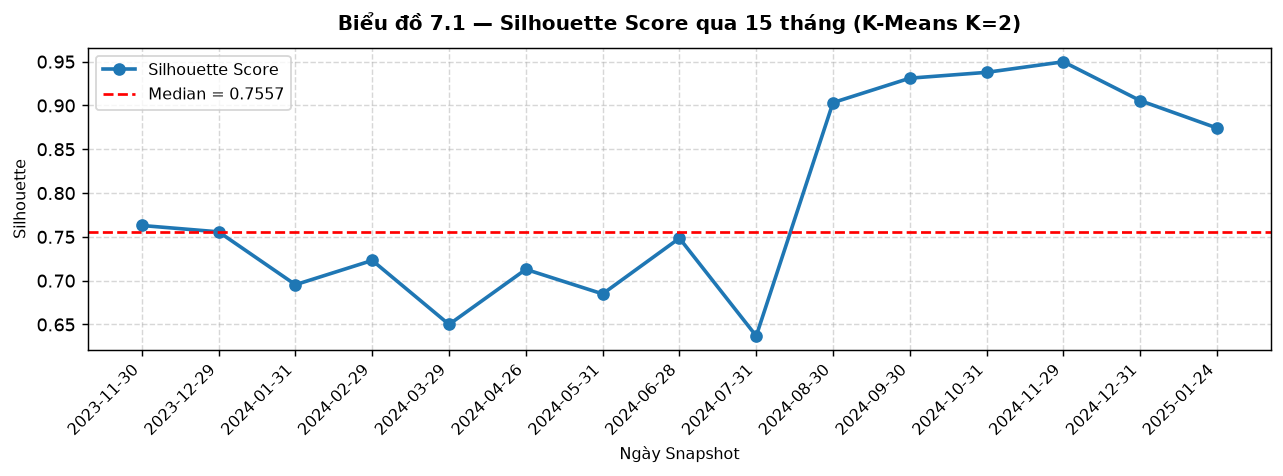

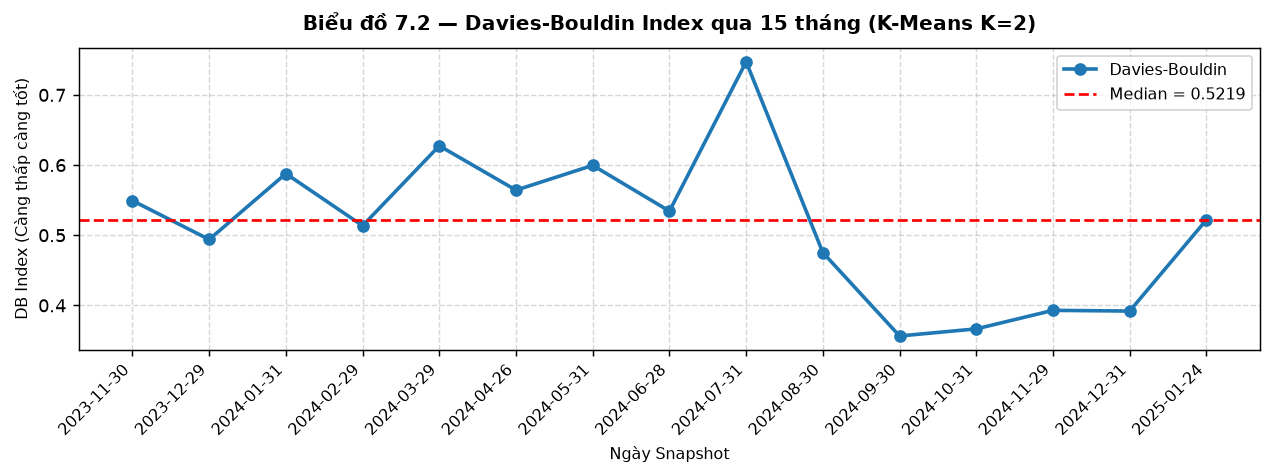

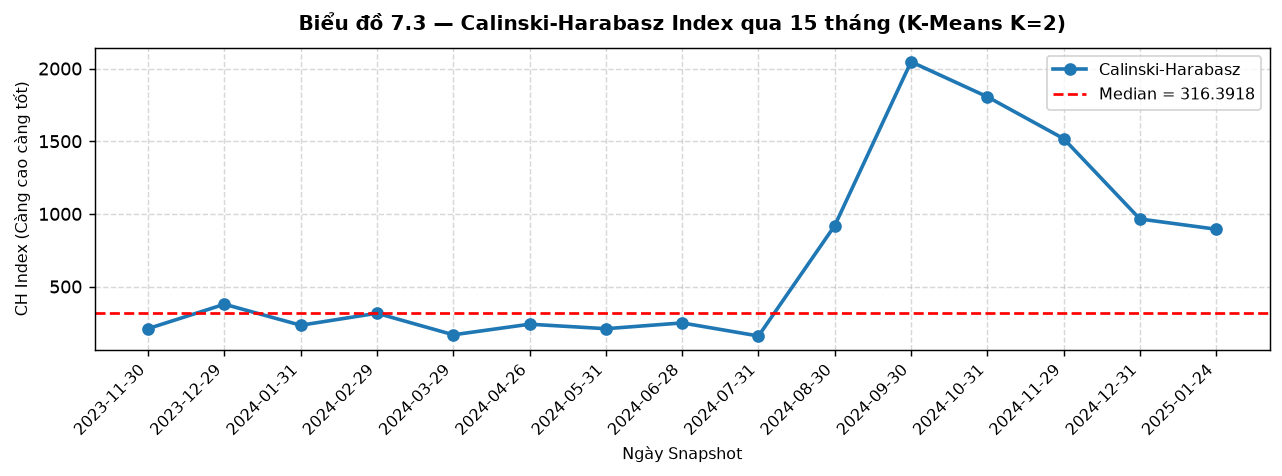

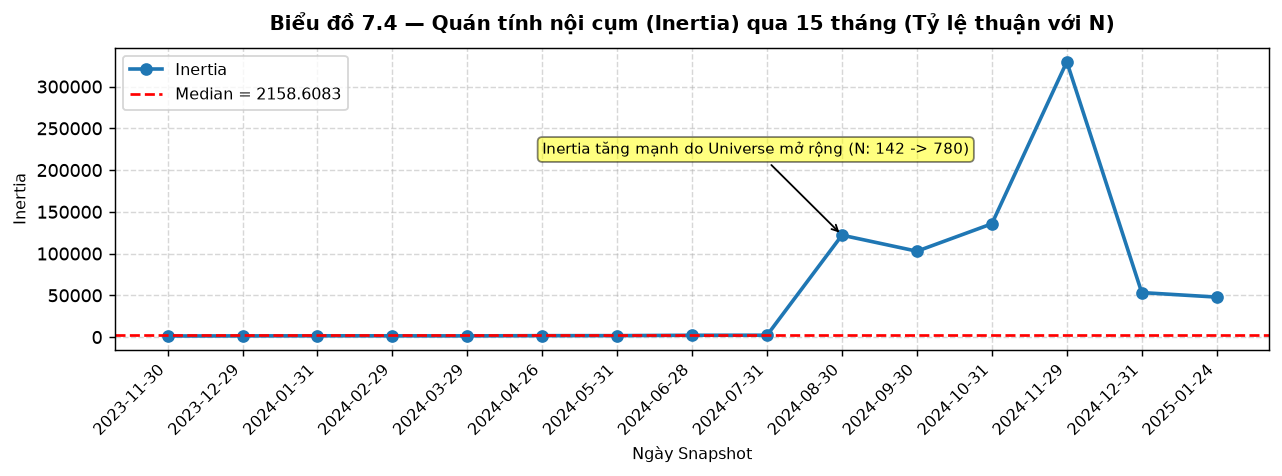

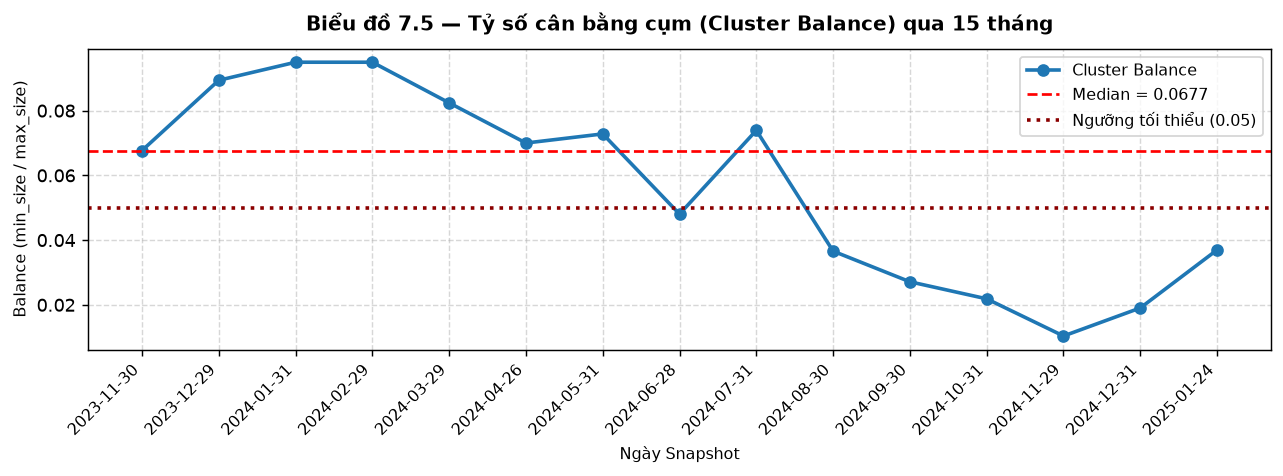

In [3]:
# =============================================================================
# TRỰC QUAN HÓA CHUẨN HÓA: 5 BIỂU ĐỒ ĐƯỜNG (VISUALIZATION CONTRACT)
# =============================================================================
snapshots = df_k2["snapshot_date"].tolist()
x_idx = range(len(snapshots))

def plot_line_metric(y_vals, metric_name, title, ylabel, plot_num, threshold=None, is_inertia=False):
    plt.figure(figsize=(10, 3.8))
    plt.plot(x_idx, y_vals, marker="o", color="#1f77b4", linewidth=2, label=f"{metric_name}")
    med_val = float(np.median(y_vals))
    plt.axhline(med_val, color="red", linestyle="--", linewidth=1.5, label=f"Median = {med_val:.4f}")
    if threshold is not None:
        plt.axhline(threshold, color="darkred", linestyle=":", linewidth=2, label=f"Ngưỡng tối thiểu ({threshold})")
    
    plt.xticks(x_idx, snapshots, rotation=45, ha="right", fontsize=9)
    plt.title(f"Biểu đồ {plot_num} — {title}", fontsize=11, fontweight="bold", pad=10)
    plt.xlabel("Ngày Snapshot", fontsize=9)
    plt.ylabel(ylabel, fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="best", fontsize=9)
    if is_inertia:
        plt.annotate("Inertia tăng mạnh do Universe mở rộng (N: 142 -> 780)", 
                     xy=(9, y_vals[9]), xytext=(5, y_vals[9]*1.8),
                     arrowprops=dict(arrowstyle="->", color="black", lw=1),
                     fontsize=8.5, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))
    plt.tight_layout()
    plt.show()

# 7.1 Silhouette Score
plot_line_metric(df_k2["silhouette"].values, "Silhouette Score", 
                 "Silhouette Score qua 15 tháng (K-Means K=2)", "Silhouette", "7.1")

# 7.2 Davies-Bouldin Index
plot_line_metric(df_k2["davies_bouldin"].values, "Davies-Bouldin", 
                 "Davies-Bouldin Index qua 15 tháng (K-Means K=2)", "DB Index (Càng thấp càng tốt)", "7.2")

# 7.3 Calinski-Harabasz Index
plot_line_metric(df_k2["calinski_harabasz"].values, "Calinski-Harabasz", 
                 "Calinski-Harabasz Index qua 15 tháng (K-Means K=2)", "CH Index (Càng cao càng tốt)", "7.3")

# 7.4 Inertia
plot_line_metric(df_k2["inertia"].values, "Inertia", 
                 "Quán tính nội cụm (Inertia) qua 15 tháng (Tỷ lệ thuận với N)", "Inertia", "7.4", is_inertia=True)

# 7.5 Cluster Balance
plot_line_metric(df_k2["cluster_balance"].values, "Cluster Balance", 
                 "Tỷ số cân bằng cụm (Cluster Balance) qua 15 tháng", "Balance (min_size / max_size)", "7.5", threshold=0.05)

## 3. Khung kết luận 3 phần bắt buộc (Academic Synthesis Framework)

### Phần A — Phán quyết Kỹ thuật (Technical Verdict):
- **Điểm mạnh toán học:** K-Means Baseline đạt điểm tách biệt hình học rất xuất sắc với **Median Silhouette = 0.7485** (vượt xa ngưỡng chấp nhận 0.50), DB Index thấp lý tưởng (**Median = 0.5219**), và Calinski-Harabasz mạnh mẽ (**Median = 316.39**). Về mặt không gian Euclid, ranh giới giữa 2 cụm được xác định cực kỳ sắc nét.
- **Điểm yếu cố hữu:** Tỷ số cân bằng cụm rất thấp (**Median Cluster Balance = 0.0480**), cụm nhỏ chỉ dao động từ 8 đến 21 mã trong khi cụm lớn chiếm từ 133 đến 772 mã. Thuật toán phân bổ trọng số khoảng cách bình phương bị chi phối mạnh bởi các quan sát ngoại lai.

### Phần B — Bản chất thị trường (Market Structure & Economics):
- Cấu trúc phân cụm của K-Means phản ánh chân thực **tính chất phân hóa dòng tiền cực đoan trên TTCK Việt Nam**: một nhóm thiểu số cổ phiếu dẫn dắt (Leader/High Momentum/Extreme Liquidity) hút phần lớn thanh khoản toàn thị trường và vận động với biên độ lớn, tách biệt hoàn toàn khỏi đại bộ phận cổ phiếu phổ thông.
- Việc không can thiệp bằng Clipping/Winsorization đã bộc lộ bản chất tự nhiên này của thị trường, làm K-Means trở thành bộ lọc nhận diện cổ phiếu ngoại lai/dẫn dắt rất nhạy bén.

### Phần C — Handoff cho Nhiệm vụ 10 (Stage Handoff):
- Mô hình **K-Means Baseline hoàn toàn đạt chuẩn chất lượng hình học và độ toàn vẹn dữ liệu** để bước vào vòng đối đầu trực tiếp tại Nhiệm vụ 10.
- Tại Nhiệm vụ 10, K-Means sẽ được so sánh đối đầu với Ward Hierarchical (vốn có xu hướng tạo cụm cân bằng hơn) và PCA + K-Means (giảm chiều không gian) trên ma trận đánh đổi 5 tiêu chí.